# Assignment 3
**Author:** Lan Stare
**Date:** 26. 9. 2025

### (a)

In [27]:
ex1 = [[6, 18, 3], 
    [2, 12, 1],
    [4, 15, 3]] #example from question (c)

ex2 = [[1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12]] #This example will raise an error because in this exercise we don't use permutation.

def lu_decomposition(matrix):
    m = len(matrix) #this is how we get the dimension from the given matrix
    
    for k in range(m):
        pivot = matrix[k][k] #we first find the pivot
        if pivot == 0:
            raise ValueError("We need to permutate the rows.") #if the value of pivot is 0 then we cannot continue
        
        for i in range(k+1, m):
            factor = matrix[i][k] / pivot #this are our lambdas from the lectures (elements of matrix L)
            matrix[i][k] = factor #storing Ls factor directly in lower part
            for j in range(k + 1, m): #num_rows = num_columns
                matrix[i][j] -= factor * matrix[k][j] #we have to update only the rest of the row
    
    return matrix 
#print(lu_decomposition(ex1))


######################################################################
""" FROM HERE EXERCISE (b) """
######################################################################

import backward_solve
import forward_solve_mod
import numpy as np

def lu_solve(matrix, b):
    """ We know that LUv = b. So first we need to get L to calculate w := Uv. Then we use backward_solve with previous function (and current matrix) to get v. """
    def construct_L(matrix):
        m = len(matrix)
        L = [[0.0] * m for _ in range(m)]
        for i in range(m):
            for j in range(m):
                if i == j:
                    L[i][j] = 1.0
                elif i > j:
                    L[i][j] = matrix[i][j]  # read stored factor
        return L

    lu_decomposition(matrix) #we have to first perform LU decomp
    L = construct_L(matrix) #this gets the L
    U = [[matrix[i][j] if j >= i else 0.0 for j in range(len(matrix))] for i in range(len(matrix))] #we can reconstruct U from matrix since we saved it that way :) 

    # Forward solve: Lw = b
    w = forward_solve_mod.forward_solve_mod(np.array(L), np.array(b))

    # Backward solve: Uv = w
    return backward_solve.backward_solve(np.array(U), w)

#print(lu_solve(ex1, [3, 19, 0]))   #We need to comment this since we overwrote the matrix and we don't want to take the ownership

######################################################################
""" FROM HERE EXERCISE (d) """
######################################################################
b = [3, 19, 0]
v = lu_solve(ex1, b)
print(v) #The solution is correct!!


[ -3.   3. -11.]


### (b) is written after (a)

This exercise could probably also be solved by iterating through b elements to put them to the last column, changing the function in (a) so it works for m x n (also when n != m) matrices and then puttind the new matrix through the function (like I did in exercise (c)).

### (c)

Note: For a faster calculation by hand I checked whether the values in each row were coprime. If they weren't, I devised them by their GCD. I did not do this in the previous exercises.

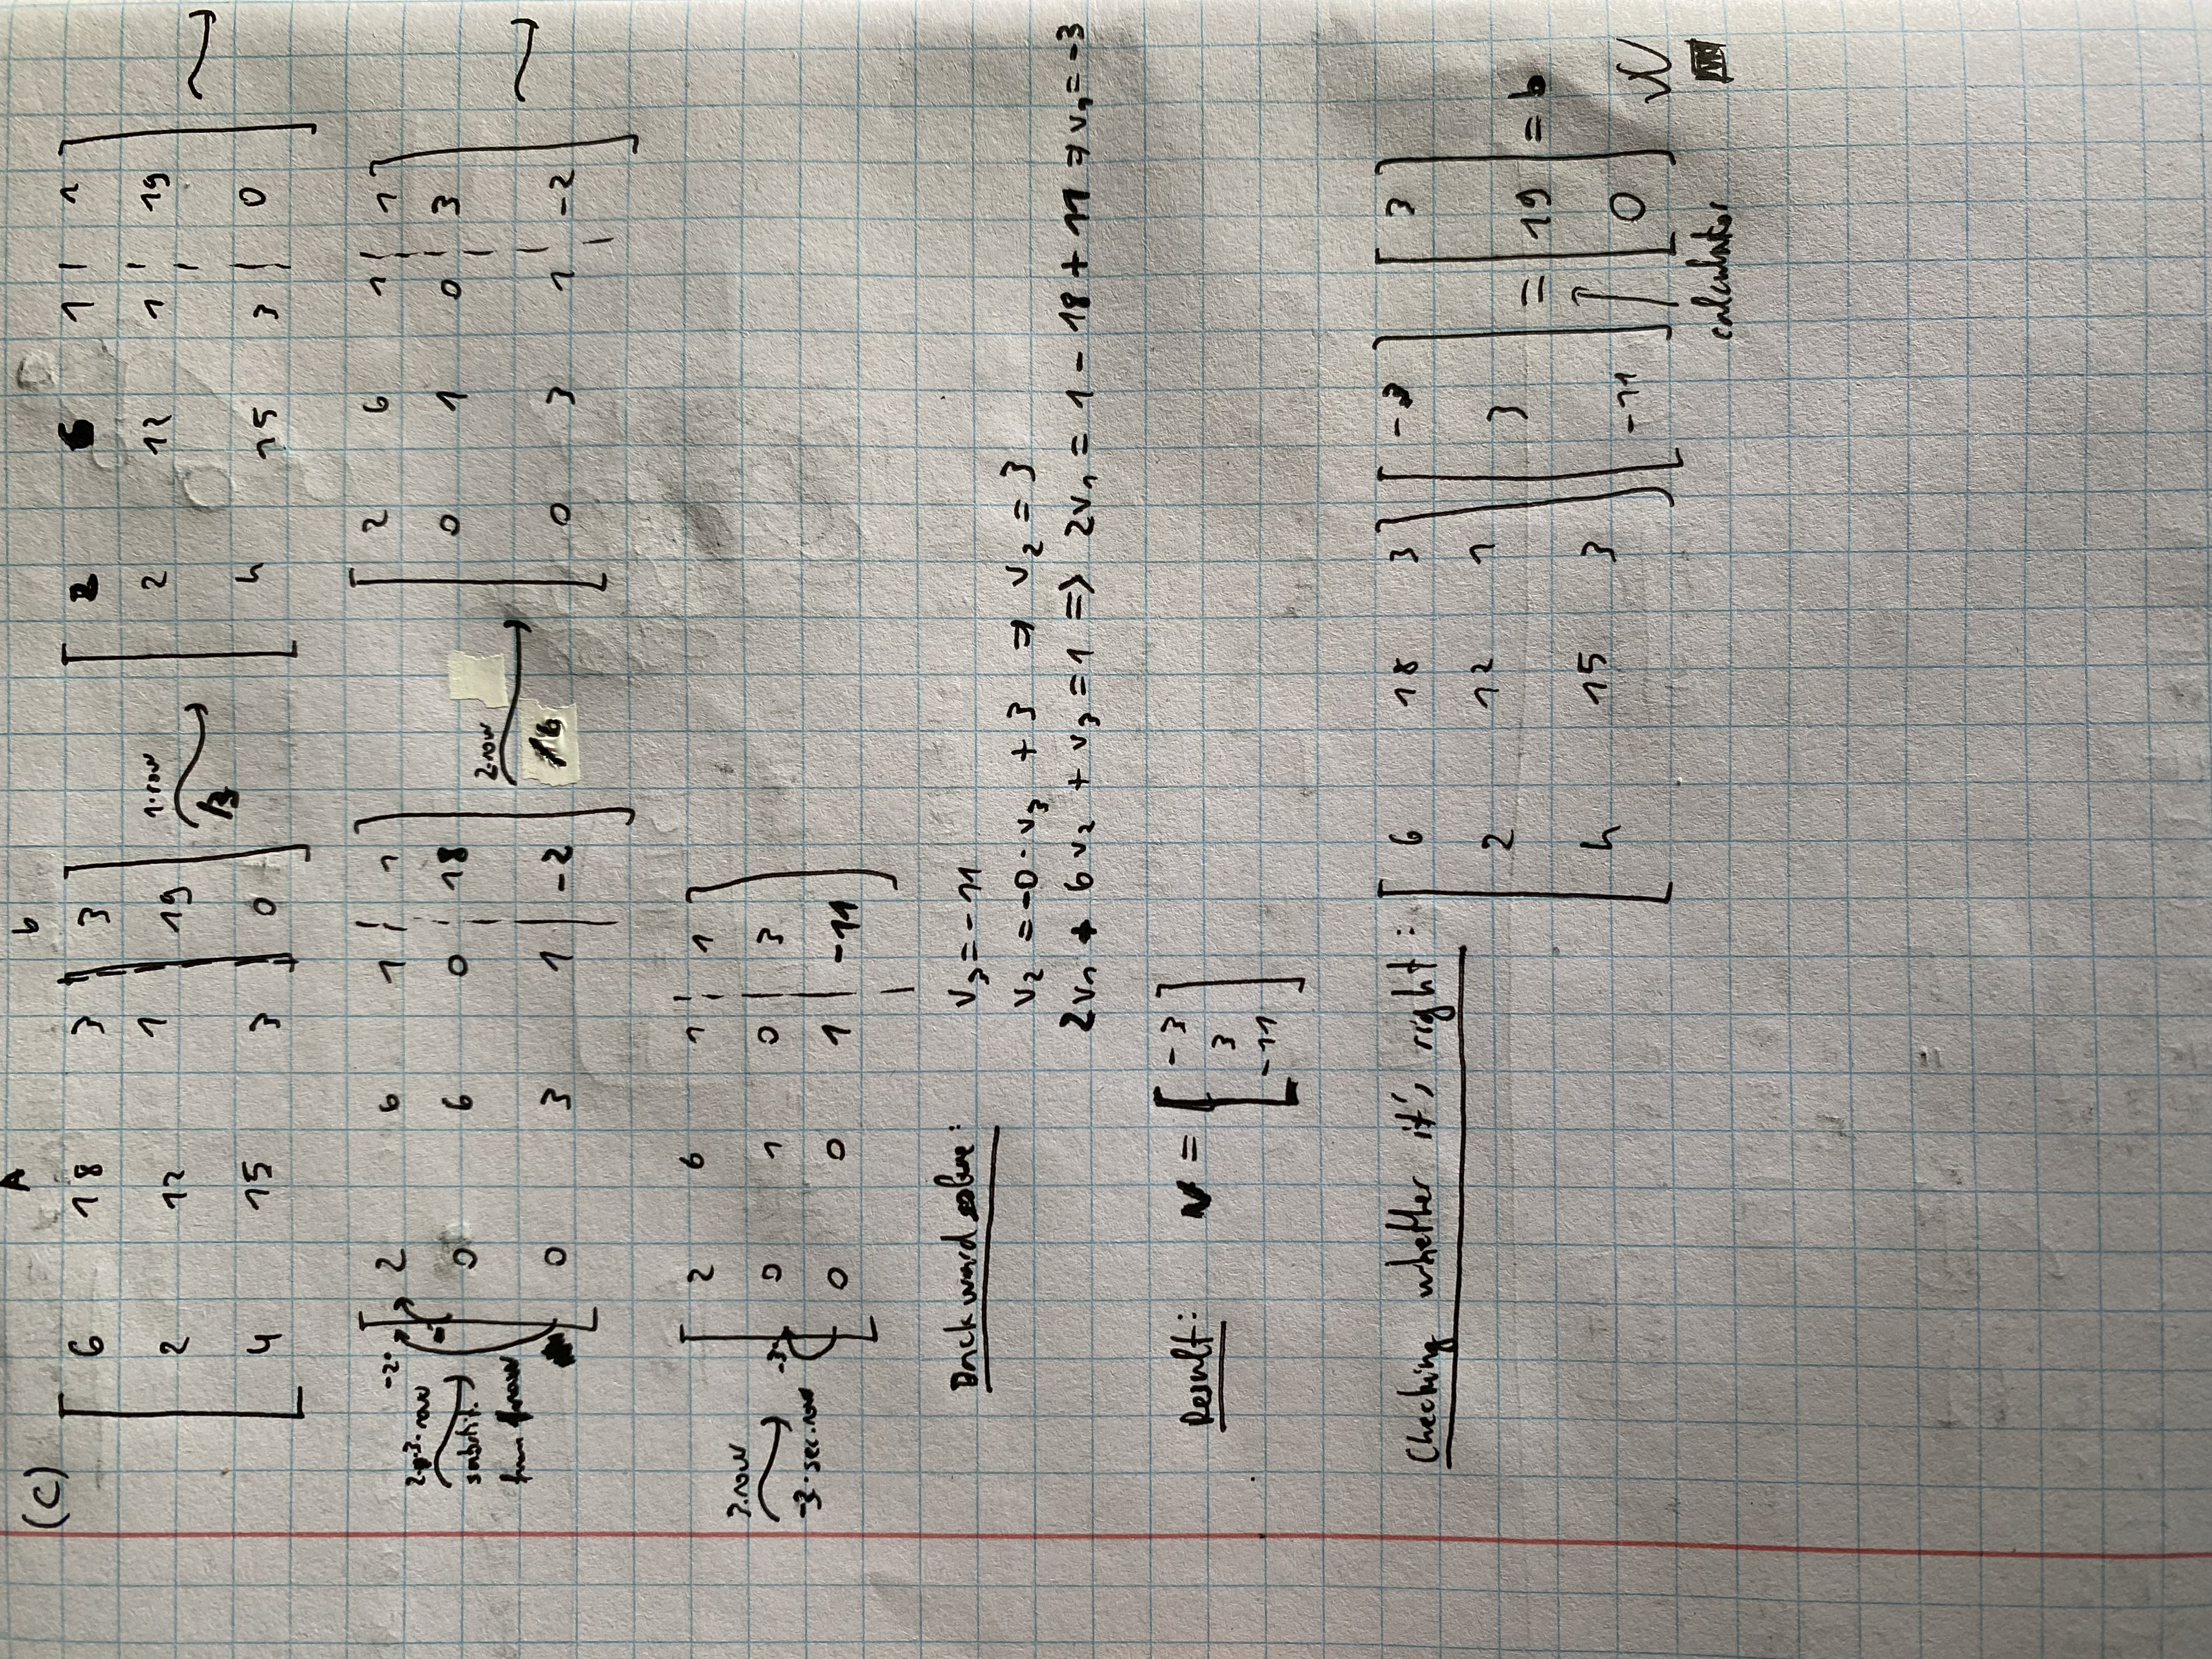

In [ ]:
from IPython.display import Image, display

# Replace with your file path
image_path = "questionC.jpeg"

display(Image(filename=image_path))

### (d) is at the end of (a)